
Dataset shape
Features: (30000, 24)
Target: (30000,)

First 5 rows
   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1      20000    2          2         1   24      2      2     -1     -1   
1   2     120000    2          2         2   26     -1      2      0      0   
2   3      90000    2          2         2   34      0      0      0      0   
3   4      50000    2          2         1   37      0      0      0      0   
4   5      50000    1          2         1   57     -1      0     -1      0   

   ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0  ...          0          0          0         0       689         0   
1  ...       3272       3455       3261         0      1000      1000   
2  ...      14331      14948      15549      1518      1500      1000   
3  ...      28314      28959      29547      2000      2019      1200   
4  ...      20940      19146      19131      2000     36681     10000   

   PAY_AMT4  PAY_A

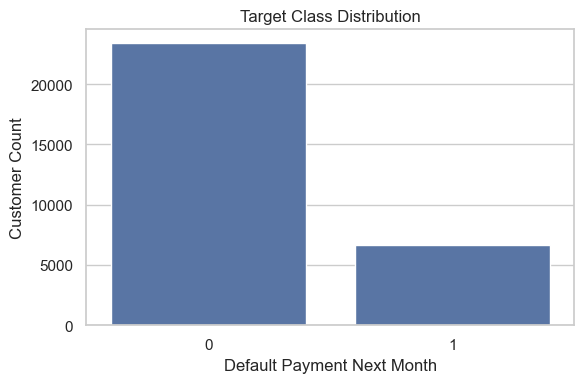

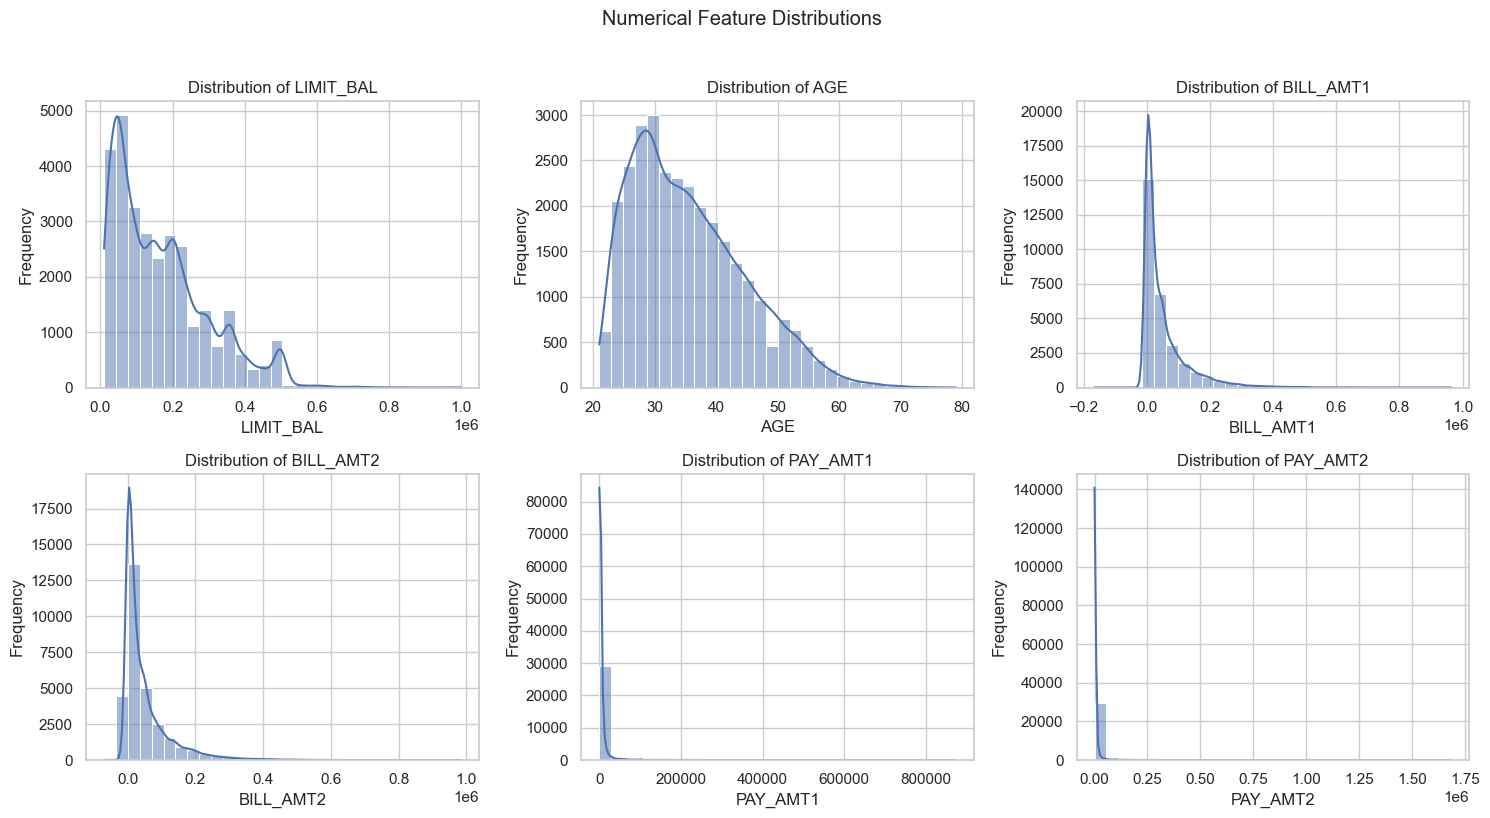

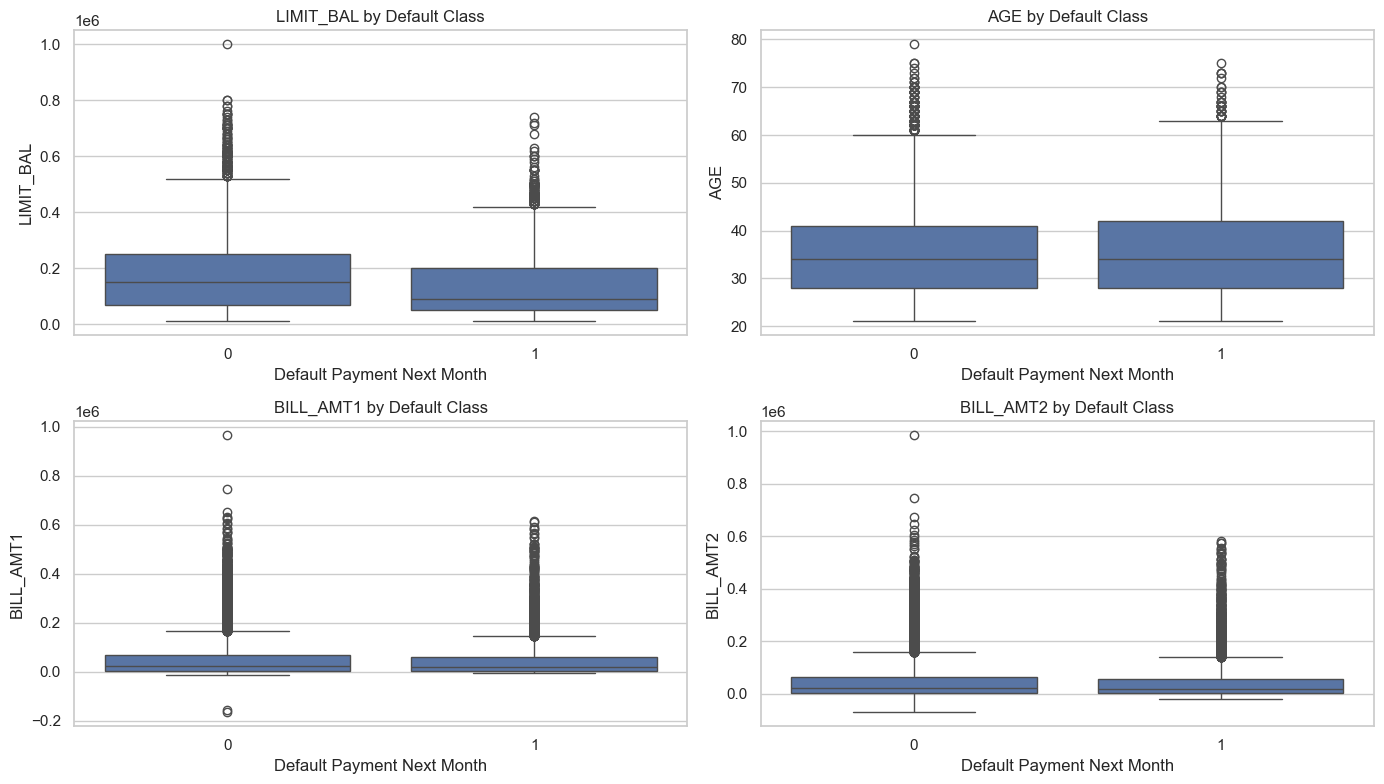

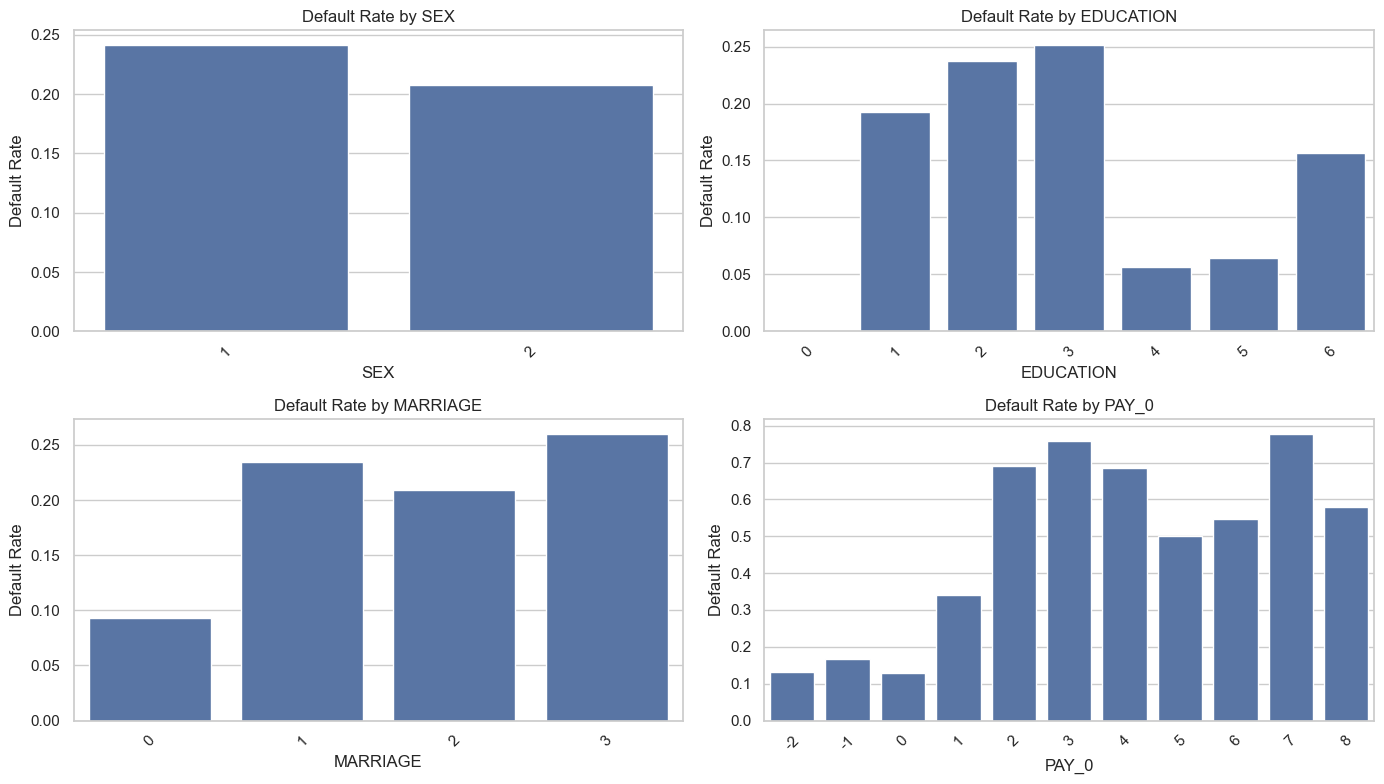

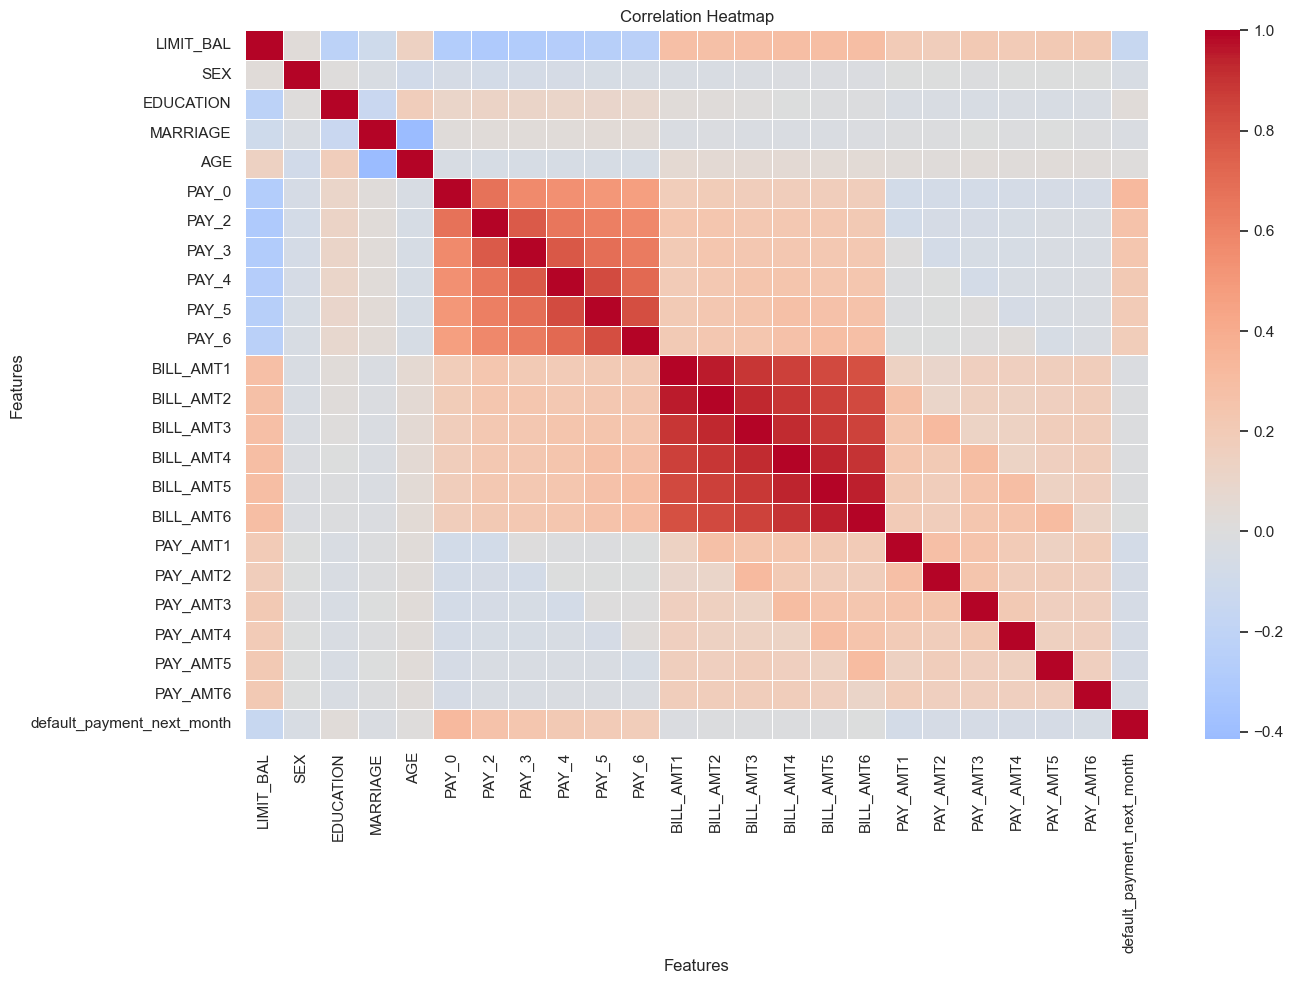

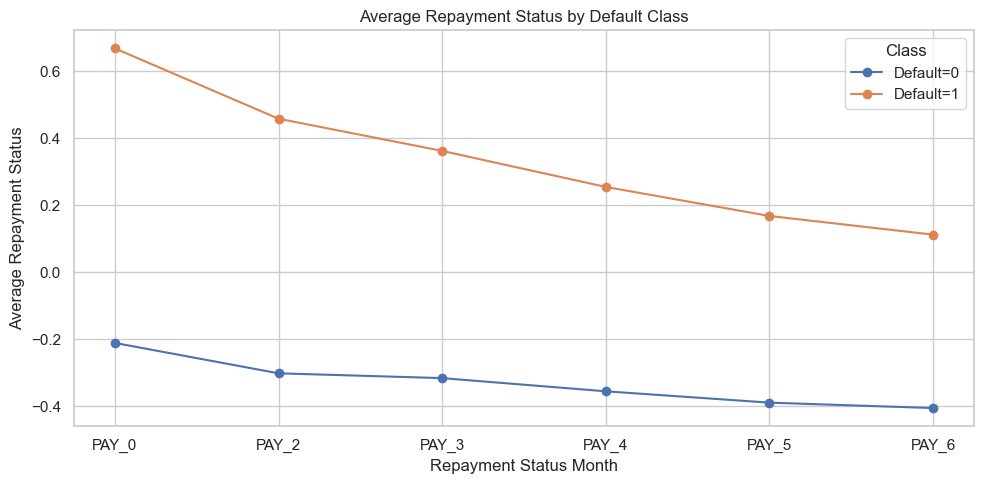

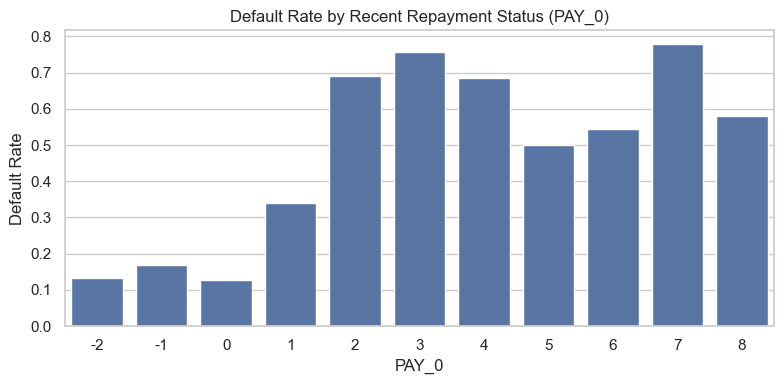

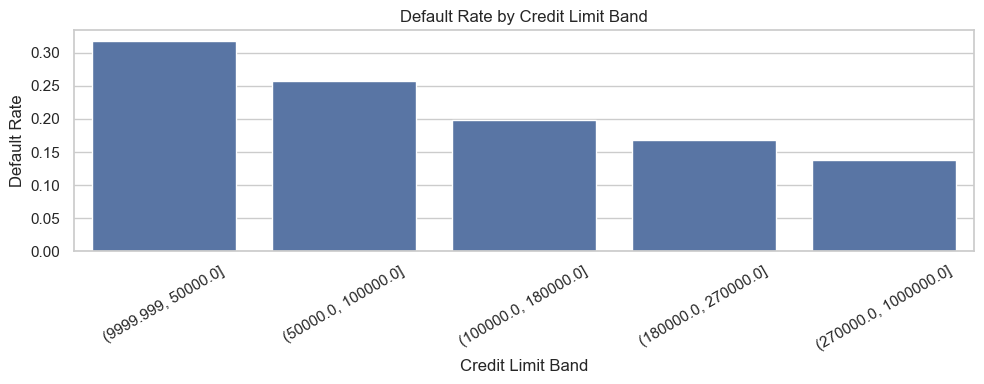

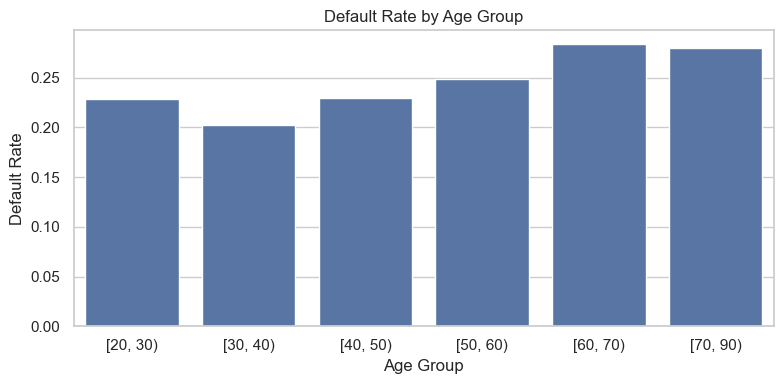

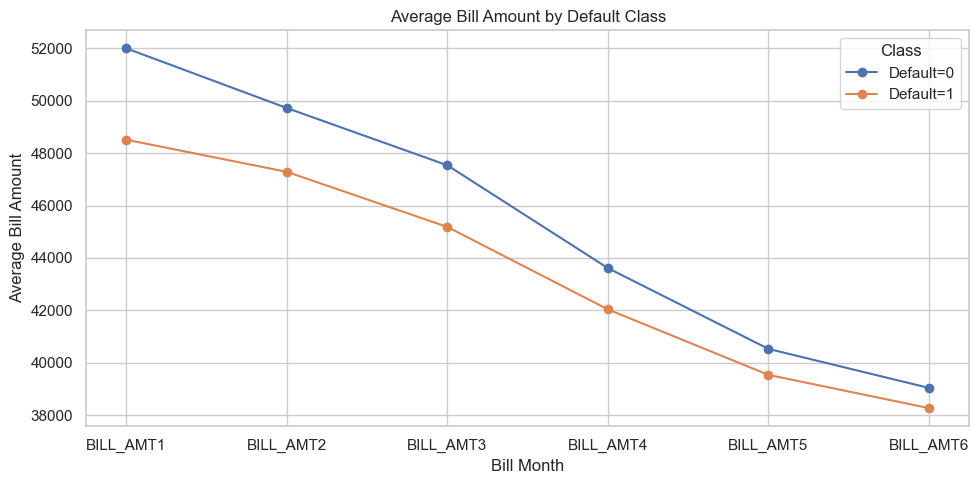

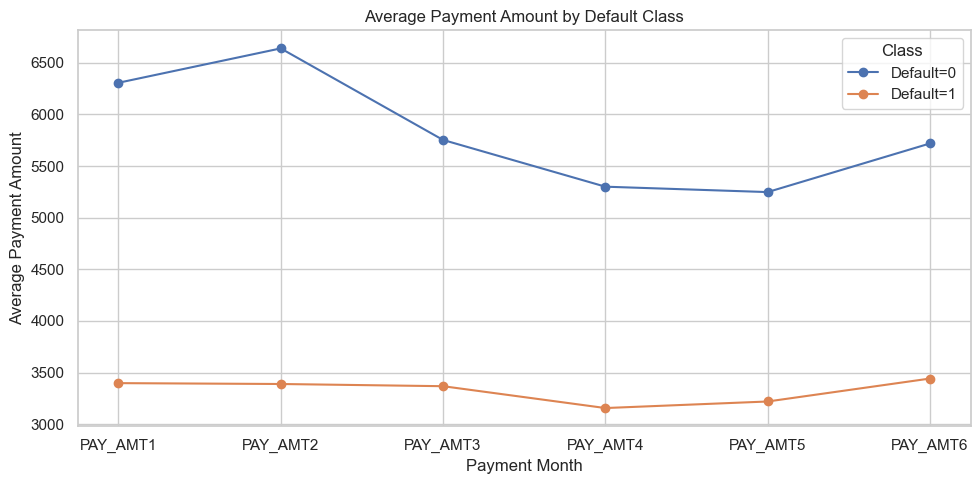


Engineered feature columns
['total_bill_amount', 'average_bill_amount', 'bill_amount_trend', 'total_payment_amount', 'average_payment_amount', 'payment_amount_trend', 'payment_to_bill_ratio', 'delayed_payment_count', 'delinquency_severity', 'recent_delayed_payment_count', 'severe_delay_flag', 'average_credit_utilization', 'maximum_credit_utilization', 'payment_to_limit_ratio']

Class distribution
                            count  percentage
default_payment_next_month                   
0                           18691    0.778792
1                            5309    0.221208

Numerical columns used in preprocessing
['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'total_bill_amount', 'average_bill_amount', 'bill_amount_trend', 'total_payment_amount', 'average_payment_amount', 'payment_amount_trend', 'payment_to_bill_ratio', 'delayed_payment_count', 'delinquency_s

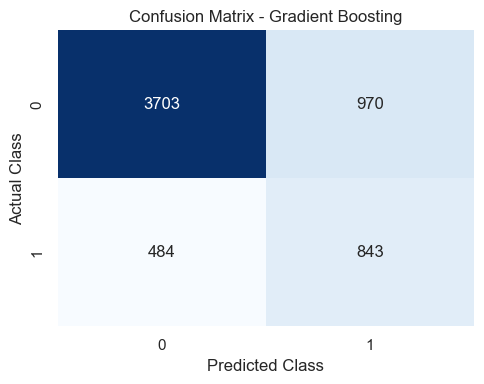

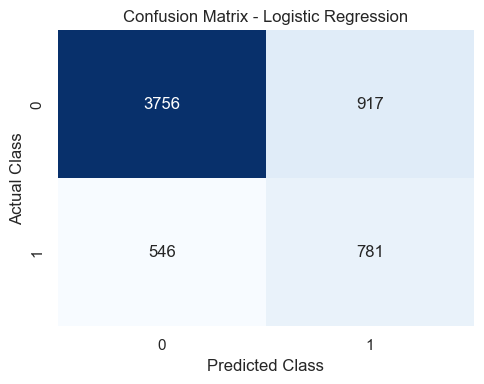

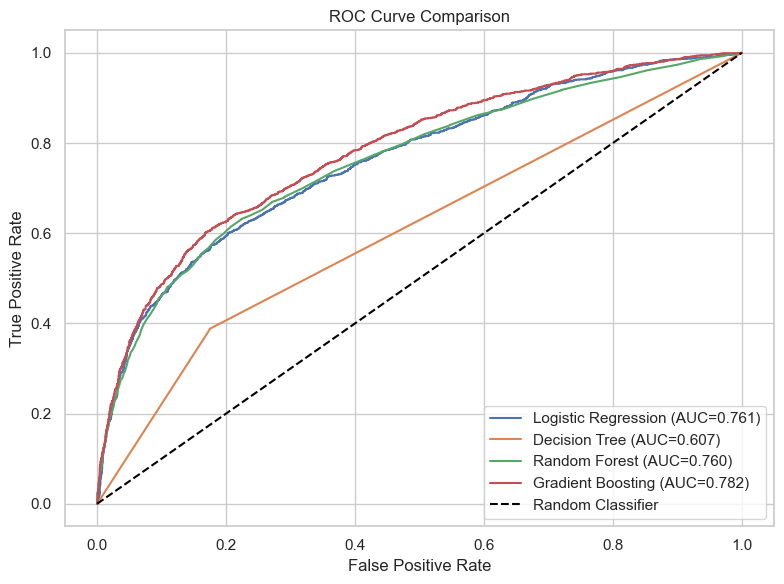

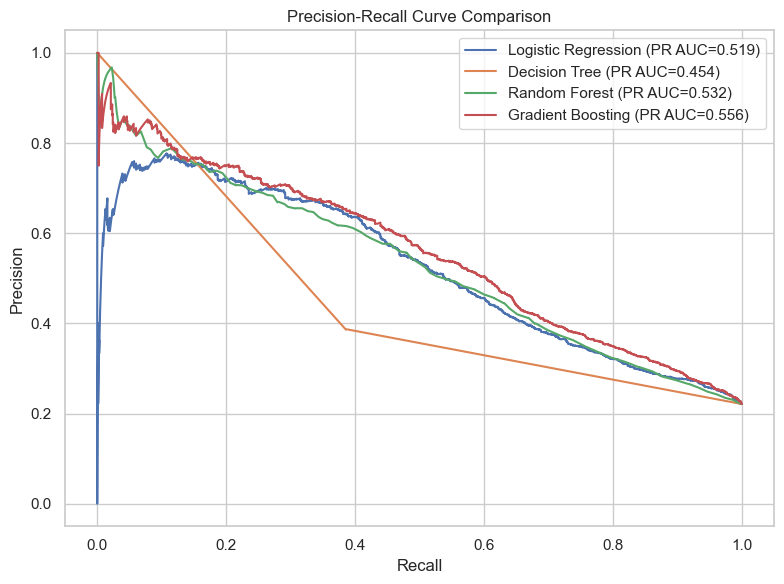


Selected models for tuning
['Gradient Boosting', 'Logistic Regression']
Fitting 2 folds for each of 2 candidates, totalling 4 fits
Fitting 2 folds for each of 2 candidates, totalling 4 fits

Hyperparameter tuning results
                 Model  Best CV ROC-AUC  \
0    Gradient Boosting         0.781961   
1  Logistic Regression         0.772006   

                                     Best Parameters  
0  {'classifier__subsample': 1.0, 'classifier__n_...  
1  {'classifier__solver': 'lbfgs', 'classifier__c...  

Tuned model test-set results
                       Model  Accuracy  Precision    Recall  F1-Score  \
0    Tuned Gradient Boosting  0.755000   0.460034  0.620196  0.528241   
1  Tuned Logistic Regression  0.816833   0.650000  0.372268  0.473407   

    ROC-AUC  
0  0.777413  
1  0.761107  

Baseline vs tuned model comparison
                          Model  Accuracy  Precision    Recall  F1-Score  \
0  Baseline Logistic Regression  0.756167   0.459953  0.588546  0.516364   
1  

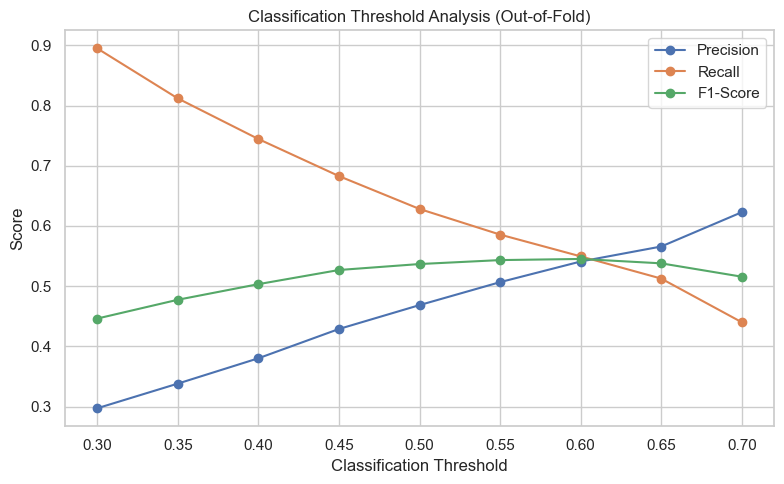


Threshold analysis
   Threshold  Precision    Recall  F1-Score
0       0.30   0.297123  0.894895  0.446124
1       0.35   0.338066  0.811829  0.477351
2       0.40   0.380146  0.744396  0.503279
3       0.45   0.428791  0.682803  0.526775
4       0.50   0.468465  0.628179  0.536691
5       0.55   0.506599  0.585609  0.543247
6       0.60   0.540886  0.549444  0.545132
7       0.65   0.565814  0.512526  0.537853
8       0.70   0.622767  0.440008  0.515673

Best tuned model test metrics at selected threshold
                     Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  Tuned Gradient Boosting  0.793333   0.532151  0.542577  0.537313  0.777413

Feature importance
                                   Feature  Importance
0         categorical__severe_delay_flag_1    0.309482
1    numeric__recent_delayed_payment_count    0.301272
2            numeric__delinquency_severity    0.089347
3                     categorical__PAY_0_2    0.062329
4           numeric__payment_to_bill

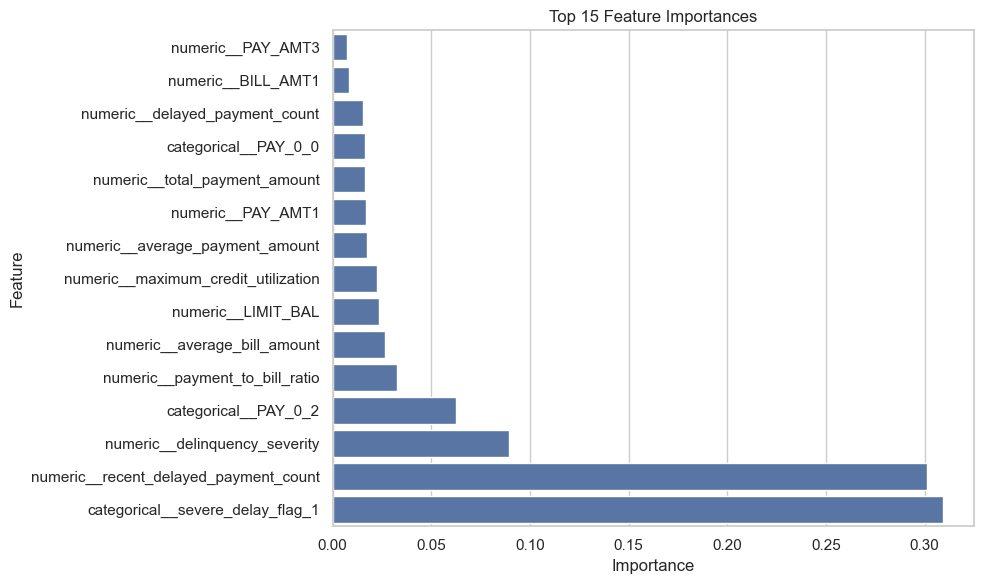


Final Model Summary
Best Model: Tuned Gradient Boosting
Best Cross-Validation ROC-AUC: 0.7820
Test Accuracy: 0.7933
Test Precision: 0.5322
Test Recall: 0.5426
Test F1-Score: 0.5373
Test ROC-AUC: 0.7774
Selected Classification Threshold: 0.60


In [2]:
# 1. Imports
import io
import os
import shutil
import ssl
import subprocess
import urllib.error
import urllib.request
import zipfile
from pathlib import Path

PROJECT_DIR = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
MPLCONFIG_DIR = Path(os.environ.get("MPLCONFIGDIR", PROJECT_DIR / ".mplconfig")).expanduser().resolve()
MPLCONFIG_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIG_DIR))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    auc,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.model_selection import cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils.class_weight import compute_sample_weight

try:
    from ucimlrepo import fetch_ucirepo
except ImportError:
    fetch_ucirepo = None

try:
    import seaborn as sns
except ImportError:
    sns = None


RANDOM_STATE = 42
N_JOBS = int(os.environ.get("ML_N_JOBS", "1"))
TUNING_CV_SPLITS = int(os.environ.get("ML_TUNING_CV_SPLITS", "2"))
TUNING_N_ITER = int(os.environ.get("ML_TUNING_N_ITER", "2"))
THRESHOLD_CV_SPLITS = int(os.environ.get("ML_THRESHOLD_CV_SPLITS", "3"))
DATA_DIR = Path(os.environ.get("ML_DATA_DIR", PROJECT_DIR / "data")).expanduser().resolve()
LOCAL_CSV_PATH = DATA_DIR / "default_of_credit_card_clients.csv"
LOCAL_XLS_PATH = DATA_DIR / "default_of_credit_card_clients.xls"
LOCAL_XLSX_PATH = DATA_DIR / "default_of_credit_card_clients.xlsx"
LOCAL_DATA_PATHS = [
    LOCAL_CSV_PATH,
    LOCAL_XLS_PATH,
    LOCAL_XLSX_PATH,
]
UCI_DATASET_ZIP_URL = "https://archive.ics.uci.edu/static/public/350/default+of+credit+card+clients.zip"

if sns is not None:
    sns.set_theme(style="whitegrid", context="notebook")
else:
    plt.style.use("ggplot")


def countplot_values(values, ax=None):
    ax = ax or plt.gca()
    if sns is not None:
        return sns.countplot(x=values, ax=ax)
    counts = pd.Series(values).value_counts().sort_index()
    ax.bar([str(index) for index in counts.index], counts.values)
    return ax


def histplot_values(values, bins=30, kde=False, ax=None):
    ax = ax or plt.gca()
    if sns is not None:
        return sns.histplot(values, bins=bins, kde=kde, ax=ax)
    ax.hist(pd.Series(values).dropna(), bins=bins)
    return ax


def boxplot_values(data, x, y, ax=None):
    ax = ax or plt.gca()
    if sns is not None:
        return sns.boxplot(data=data, x=x, y=y, ax=ax)
    grouped = data[[x, y]].dropna().groupby(x, sort=True)
    labels = []
    values = []
    for label, group in grouped:
        labels.append(str(label))
        values.append(group[y].to_numpy())
    try:
        ax.boxplot(values, tick_labels=labels)
    except TypeError:
        ax.boxplot(values, labels=labels)
    return ax


def barplot_values(data, x, y, ax=None):
    ax = ax or plt.gca()
    if sns is not None:
        return sns.barplot(data=data, x=x, y=y, ax=ax)
    if pd.api.types.is_numeric_dtype(data[x]) and not pd.api.types.is_numeric_dtype(data[y]):
        ax.barh(data[y].astype(str), data[x])
    else:
        ax.bar(data[x].astype(str), data[y])
    return ax


def heatmap_values(data, ax=None, annot=False, fmt="d", cmap="Blues", cbar=False, center=None, linewidths=0.0):
    ax = ax or plt.gca()
    if sns is not None:
        return sns.heatmap(data, annot=annot, fmt=fmt, cmap=cmap, cbar=cbar, ax=ax, center=center, linewidths=linewidths)
    values = np.asarray(data)
    vmin, vmax = (-1, 1) if center == 0 else (None, None)
    image = ax.imshow(values, cmap=cmap, aspect="auto", vmin=vmin, vmax=vmax)
    ax.set_xticks(np.arange(values.shape[1]))
    ax.set_yticks(np.arange(values.shape[0]))
    if hasattr(data, "columns"):
        ax.set_xticklabels(data.columns, rotation=90)
    if hasattr(data, "index"):
        ax.set_yticklabels(data.index)
    if annot:
        for row_index in range(values.shape[0]):
            for column_index in range(values.shape[1]):
                ax.text(column_index, row_index, format(values[row_index, column_index], fmt), ha="center", va="center")
    if cbar:
        plt.colorbar(image, ax=ax)
    return ax


def show_or_close_plot():
    if plt.get_backend().lower() == "agg":
        plt.close()
    else:
        plt.show()


# 2. Data Loading

def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def clean_column_names(dataframe):
    cleaned = dataframe.copy()
    cleaned.columns = [str(column).strip().replace(" ", "_") for column in cleaned.columns]
    return cleaned


def normalize_target(target_data):
    target = target_data.squeeze()
    if isinstance(target, pd.DataFrame):
        target = target.iloc[:, 0]
    target = pd.Series(target).reset_index(drop=True)
    target.name = "default_payment_next_month"
    return pd.to_numeric(target, errors="raise").astype(int)


def identify_target_column(dataframe):
    normalized_columns = {column: str(column).strip().lower().replace(" ", "_") for column in dataframe.columns}
    target_names = {
        "y",
        "default_payment_next_month",
        "default.payment.next.month",
        "default_payment_next_month.",
    }

    for column, normalized in normalized_columns.items():
        if normalized in target_names:
            return column

    for column, normalized in normalized_columns.items():
        if "default" in normalized and "next" in normalized and "month" in normalized:
            return column

    raise ValueError("Target column not found. Expected Y or default payment next month.")


def _check_excel_engine_available(engine_name):
    import importlib.util

    return importlib.util.find_spec(engine_name) is not None


def read_excel_with_helpful_error(path, header=1):
    suffix = path.suffix.lower()
    engine = "xlrd" if suffix == ".xls" else "openpyxl"
    if not _check_excel_engine_available(engine):
        raise ImportError(
            f"\nCannot read '{path.name}': pandas needs the '{engine}' package for "
            f"{suffix} files, and the automatic CSV conversion was not available.\n\n"
            f"Fix this by running one of these commands, then re-running the script:\n"
            f"    pip install {engine}\n"
            f"    conda install {engine}\n\n"
            f"Alternatively, save the dataset as CSV at:\n"
            f"    {LOCAL_CSV_PATH}"
        )
    return pd.read_excel(path, header=header, engine=engine)


def _normalize_header_cell(value):
    return str(value).strip().lower().replace(".", "_").replace(" ", "_")


def read_csv_with_detected_header(path):
    preview = pd.read_csv(path, header=None, nrows=2)
    header = 0
    if len(preview) > 1:
        second_row_values = {_normalize_header_cell(value) for value in preview.iloc[1].dropna()}
        if {"limit_bal", "default_payment_next_month"} & second_row_values:
            header = 1
    return pd.read_csv(path, header=header), header


def find_soffice():
    possible_paths = [
        shutil.which("soffice"),
        Path.home() / ".cache/codex-runtimes/codex-primary-runtime/dependencies/bin/override/soffice",
        Path("/Applications/LibreOffice.app/Contents/MacOS/soffice"),
        Path("/opt/homebrew/bin/soffice"),
        Path("/usr/local/bin/soffice"),
    ]
    for possible_path in possible_paths:
        if possible_path is None:
            continue
        path = Path(possible_path).expanduser()
        if path.exists() and os.access(path, os.X_OK):
            return str(path)
    return None


def convert_excel_to_csv_with_soffice(excel_path, csv_path=LOCAL_CSV_PATH):
    soffice = find_soffice()
    if soffice is None:
        return False

    csv_path.parent.mkdir(parents=True, exist_ok=True)
    completed = subprocess.run(
        [
            soffice,
            "--headless",
            "--convert-to",
            "csv",
            "--outdir",
            str(csv_path.parent),
            str(excel_path),
        ],
        check=False,
        capture_output=True,
        text=True,
    )
    converted_path = csv_path.parent / f"{excel_path.stem}.csv"
    if completed.returncode != 0 or not converted_path.exists():
        message = (completed.stderr or completed.stdout).strip()
        print(f"Excel-to-CSV conversion failed with soffice: {message}")
        return False

    if converted_path != csv_path:
        converted_path.replace(csv_path)
    return True


def download_uci_dataset(destination_dir=DATA_DIR):
    destination_dir.mkdir(parents=True, exist_ok=True)
    request = urllib.request.Request(UCI_DATASET_ZIP_URL, headers={"User-Agent": "Mozilla/5.0"})
    try:
        with urllib.request.urlopen(request, timeout=30) as response:
            zip_bytes = response.read()
    except urllib.error.URLError as error:
        if "CERTIFICATE_VERIFY_FAILED" not in str(error):
            raise
        print("SSL certificate verification failed. Retrying the official UCI URL with an unverified SSL context.")
        context = ssl._create_unverified_context()
        with urllib.request.urlopen(request, timeout=30, context=context) as response:
            zip_bytes = response.read()

    with zipfile.ZipFile(io.BytesIO(zip_bytes)) as archive:
        xls_members = [name for name in archive.namelist() if name.lower().endswith(".xls")]
        if not xls_members:
            raise RuntimeError("Downloaded archive did not contain an .xls dataset file.")
        with archive.open(xls_members[0]) as source, LOCAL_XLS_PATH.open("wb") as target:
            shutil.copyfileobj(source, target)

    if convert_excel_to_csv_with_soffice(LOCAL_XLS_PATH):
        return LOCAL_CSV_PATH
    return LOCAL_XLS_PATH


def cache_ucimlrepo_dataset():
    dataset = fetch_ucirepo(id=350)
    X = clean_column_names(dataset.data.features.copy())
    y = normalize_target(dataset.data.targets.copy())
    LOCAL_CSV_PATH.parent.mkdir(parents=True, exist_ok=True)
    pd.concat([X, y], axis=1).to_csv(LOCAL_CSV_PATH, index=False)
    return LOCAL_CSV_PATH


def load_local_uci_dataset():
    existing_paths = [path for path in LOCAL_DATA_PATHS if path.exists()]
    if not existing_paths:
        expected_paths = "\n".join(f"- {path}" for path in LOCAL_DATA_PATHS)
        raise FileNotFoundError(
            "No local dataset was found and automatic downloads failed.\n"
            "Download the official UCI Default of Credit Card Clients dataset and place it at one of:\n"
            f"{expected_paths}\n"
            "Official download page: https://archive.ics.uci.edu/dataset/350"
        )

    local_path = existing_paths[0]
    csv_header = 0
    if local_path.suffix.lower() == ".csv":
        raw_data, csv_header = read_csv_with_detected_header(local_path)
    elif convert_excel_to_csv_with_soffice(local_path):
        local_path = LOCAL_CSV_PATH
        raw_data, csv_header = read_csv_with_detected_header(local_path)
    elif local_path.suffix.lower() in {".xls", ".xlsx"}:
        raw_data = read_excel_with_helpful_error(local_path, header=1)
    else:
        raise ValueError(f"Unsupported dataset file format: {local_path}")

    raw_data = clean_column_names(raw_data)
    if local_path != LOCAL_CSV_PATH or csv_header != 0:
        raw_data.to_csv(LOCAL_CSV_PATH, index=False)
    target_column = identify_target_column(raw_data)
    y = normalize_target(raw_data[target_column])
    X = raw_data.drop(columns=[target_column])
    return X, y


def load_dataset():
    if not any(path.exists() for path in LOCAL_DATA_PATHS):
        if fetch_ucirepo is not None:
            try:
                print(f"No local dataset found. Downloading and caching UCI dataset at {LOCAL_CSV_PATH}...")
                cache_ucimlrepo_dataset()
            except Exception as error:
                print(f"Automatic UCI download via ucimlrepo failed: {error}")
        else:
            print("ucimlrepo is not installed; trying a direct UCI download instead.")

    if not any(path.exists() for path in LOCAL_DATA_PATHS):
        print(f"No local dataset file found. Downloading from UCI to {DATA_DIR}...")
        try:
            downloaded_path = download_uci_dataset()
            print(f"Download succeeded. Cached dataset is available at {downloaded_path}.")
        except Exception as error:
            print(f"Direct UCI download failed: {error}")
    return load_local_uci_dataset()


def display_dataset_overview(X, y):
    print("\nDataset shape")
    print(f"Features: {X.shape}")
    print(f"Target: {y.shape}")

    print("\nFirst 5 rows")
    print(pd.concat([X, y], axis=1).head())

    print("\nColumn names")
    print(X.columns.tolist())

    print("\nData types")
    print(X.dtypes)

    print("\nDescriptive statistics")
    print(X.describe(include="all").T)

    print("\nTarget variable")
    print(y.name)


# 3. Data Quality Checks

def display_data_quality_checks(X, y):
    print("\nMissing values")
    missing_values = pd.concat([X, y], axis=1).isna().sum()
    if missing_values.sum() == 0:
        print("No missing values found.")
    else:
        print(missing_values[missing_values > 0].sort_values(ascending=False))

    print("\nDuplicate rows")
    print(X.duplicated().sum())

    print("\nUnique value counts")
    print(X.nunique(dropna=False).sort_values())

    print("\nData-type check")
    print(X.dtypes.value_counts())

    print("\nTarget distribution")
    target_distribution = y.value_counts().sort_index().to_frame("count")
    target_distribution["percentage"] = target_distribution["count"] / len(y)
    print(target_distribution)


def remove_identifier_columns(X):
    identifier_columns = [
        column
        for column in X.columns
        if str(column).strip().lower() in {"id", "client_id", "customer_id"}
    ]
    if identifier_columns:
        print(f"\nDropping identifier columns before EDA/modeling: {identifier_columns}")
    return X.drop(columns=identifier_columns, errors="ignore")


def get_column_groups(X):
    aliases = {
        "limit": ["LIMIT_BAL", "X1"],
        "sex": ["SEX", "X2"],
        "education": ["EDUCATION", "X3"],
        "marriage": ["MARRIAGE", "X4"],
        "age": ["AGE", "X5"],
    }

    selected = {}
    for key, candidates in aliases.items():
        selected[key] = next((column for column in candidates if column in X.columns), None)

    repayment_columns = [column for column in ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"] if column in X.columns]
    if not repayment_columns:
        repayment_columns = [column for column in [f"X{i}" for i in range(6, 12)] if column in X.columns]

    bill_columns = [column for column in [f"BILL_AMT{i}" for i in range(1, 7)] if column in X.columns]
    if not bill_columns:
        bill_columns = [column for column in [f"X{i}" for i in range(12, 18)] if column in X.columns]

    payment_columns = [column for column in [f"PAY_AMT{i}" for i in range(1, 7)] if column in X.columns]
    if not payment_columns:
        payment_columns = [column for column in [f"X{i}" for i in range(18, 24)] if column in X.columns]

    selected["repayment"] = repayment_columns
    selected["bill"] = bill_columns
    selected["payment"] = payment_columns
    return selected


# 4. EDA

def plot_target_distribution(y):
    plt.figure(figsize=(6, 4))
    countplot_values(y)
    plt.title("Target Class Distribution")
    plt.xlabel("Default Payment Next Month")
    plt.ylabel("Customer Count")
    plt.tight_layout()
    show_or_close_plot()


def plot_numerical_distributions(X, columns):
    columns = [column for column in columns if column in X.columns]
    if not columns:
        return

    rows = int(np.ceil(len(columns) / 3))
    fig, axes = plt.subplots(rows, 3, figsize=(15, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for axis, column in zip(axes, columns):
        histplot_values(X[column], bins=30, kde=True, ax=axis)
        axis.set_title(f"Distribution of {column}")
        axis.set_xlabel(column)
        axis.set_ylabel("Frequency")

    for axis in axes[len(columns):]:
        axis.remove()

    fig.suptitle("Numerical Feature Distributions", y=1.02)
    plt.tight_layout()
    show_or_close_plot()


def plot_boxplots_by_target(X, y, columns):
    columns = [column for column in columns if column in X.columns]
    if not columns:
        return

    rows = int(np.ceil(len(columns) / 2))
    fig, axes = plt.subplots(rows, 2, figsize=(14, 4 * rows))
    axes = np.array(axes).reshape(-1)
    plot_data = pd.concat([X, y], axis=1)

    for axis, column in zip(axes, columns):
        boxplot_values(data=plot_data, x=y.name, y=column, ax=axis)
        axis.set_title(f"{column} by Default Class")
        axis.set_xlabel("Default Payment Next Month")
        axis.set_ylabel(column)

    for axis in axes[len(columns):]:
        axis.remove()

    plt.tight_layout()
    show_or_close_plot()


def plot_default_rate_by_categories(X, y, columns):
    columns = [column for column in columns if column in X.columns]
    if not columns:
        return

    rows = int(np.ceil(len(columns) / 2))
    fig, axes = plt.subplots(rows, 2, figsize=(14, 4 * rows))
    axes = np.array(axes).reshape(-1)
    plot_data = pd.concat([X, y], axis=1)

    for axis, column in zip(axes, columns):
        default_rates = plot_data.groupby(column, observed=False)[y.name].mean().reset_index()
        barplot_values(data=default_rates, x=column, y=y.name, ax=axis)
        axis.set_title(f"Default Rate by {column}")
        axis.set_xlabel(column)
        axis.set_ylabel("Default Rate")
        axis.tick_params(axis="x", rotation=45)

    for axis in axes[len(columns):]:
        axis.remove()

    plt.tight_layout()
    show_or_close_plot()


def plot_correlation_heatmap(X, y):
    numeric_data = pd.concat([X.select_dtypes(include=np.number), y], axis=1)
    if numeric_data.shape[1] < 2:
        return

    correlation = numeric_data.corr()
    plt.figure(figsize=(14, 10))
    heatmap_values(correlation, cmap="coolwarm", center=0, linewidths=0.5, cbar=True)
    plt.title("Correlation Heatmap")
    plt.xlabel("Features")
    plt.ylabel("Features")
    plt.tight_layout()
    show_or_close_plot()


def plot_repayment_status_analysis(X, y, repayment_columns):
    repayment_columns = [column for column in repayment_columns if column in X.columns]
    if not repayment_columns:
        return

    plot_data = pd.concat([X[repayment_columns], y], axis=1)
    average_status = plot_data.groupby(y.name)[repayment_columns].mean().T.reset_index()
    average_status = average_status.rename(columns={"index": "Repayment Month"})

    plt.figure(figsize=(10, 5))
    for default_class in sorted(y.unique()):
        plt.plot(
            average_status["Repayment Month"],
            average_status[default_class],
            marker="o",
            label=f"Default={default_class}",
        )
    plt.title("Average Repayment Status by Default Class")
    plt.xlabel("Repayment Status Month")
    plt.ylabel("Average Repayment Status")
    plt.legend(title="Class")
    plt.tight_layout()
    show_or_close_plot()

    recent_status = repayment_columns[0]
    default_rate = plot_data.groupby(recent_status, observed=False)[y.name].mean().reset_index()
    plt.figure(figsize=(8, 4))
    barplot_values(data=default_rate, x=recent_status, y=y.name)
    plt.title(f"Default Rate by Recent Repayment Status ({recent_status})")
    plt.xlabel(recent_status)
    plt.ylabel("Default Rate")
    plt.tight_layout()
    show_or_close_plot()


def plot_credit_limit_analysis(X, y, limit_column):
    if limit_column is None or limit_column not in X.columns:
        return

    plot_data = pd.DataFrame(
        {
            limit_column: X[limit_column],
            y.name: y,
            "credit_limit_band": pd.qcut(X[limit_column], q=5, duplicates="drop"),
        }
    )
    default_rates = plot_data.groupby("credit_limit_band", observed=False)[y.name].mean().reset_index()

    plt.figure(figsize=(10, 4))
    barplot_values(data=default_rates, x="credit_limit_band", y=y.name)
    plt.title("Default Rate by Credit Limit Band")
    plt.xlabel("Credit Limit Band")
    plt.ylabel("Default Rate")
    plt.tick_params(axis="x", rotation=30)
    plt.tight_layout()
    show_or_close_plot()


def plot_age_analysis(X, y, age_column):
    if age_column is None or age_column not in X.columns:
        return

    age_bins = [20, 30, 40, 50, 60, 70, 90]
    plot_data = pd.DataFrame(
        {
            age_column: X[age_column],
            y.name: y,
            "age_group": pd.cut(X[age_column], bins=age_bins, right=False),
        }
    )
    default_rates = plot_data.groupby("age_group", observed=False)[y.name].mean().reset_index()

    plt.figure(figsize=(8, 4))
    barplot_values(data=default_rates, x="age_group", y=y.name)
    plt.title("Default Rate by Age Group")
    plt.xlabel("Age Group")
    plt.ylabel("Default Rate")
    plt.tight_layout()
    show_or_close_plot()


def plot_bill_payment_analysis(X, y, bill_columns, payment_columns):
    bill_columns = [column for column in bill_columns if column in X.columns]
    payment_columns = [column for column in payment_columns if column in X.columns]

    if bill_columns:
        bill_data = pd.concat([X[bill_columns], y], axis=1)
        average_bills = bill_data.groupby(y.name)[bill_columns].mean().T.reset_index()
        average_bills = average_bills.rename(columns={"index": "Bill Month"})

        plt.figure(figsize=(10, 5))
        for default_class in sorted(y.unique()):
            plt.plot(average_bills["Bill Month"], average_bills[default_class], marker="o", label=f"Default={default_class}")
        plt.title("Average Bill Amount by Default Class")
        plt.xlabel("Bill Month")
        plt.ylabel("Average Bill Amount")
        plt.legend(title="Class")
        plt.tight_layout()
        show_or_close_plot()

    if payment_columns:
        payment_data = pd.concat([X[payment_columns], y], axis=1)
        average_payments = payment_data.groupby(y.name)[payment_columns].mean().T.reset_index()
        average_payments = average_payments.rename(columns={"index": "Payment Month"})

        plt.figure(figsize=(10, 5))
        for default_class in sorted(y.unique()):
            plt.plot(
                average_payments["Payment Month"],
                average_payments[default_class],
                marker="o",
                label=f"Default={default_class}",
            )
        plt.title("Average Payment Amount by Default Class")
        plt.xlabel("Payment Month")
        plt.ylabel("Average Payment Amount")
        plt.legend(title="Class")
        plt.tight_layout()
        show_or_close_plot()


def run_eda(X, y, column_groups):
    important_numeric_columns = [
        column_groups["limit"],
        column_groups["age"],
        *column_groups["bill"][:2],
        *column_groups["payment"][:2],
    ]
    important_numeric_columns = [column for column in important_numeric_columns if column is not None]

    categorical_columns = [
        column_groups["sex"],
        column_groups["education"],
        column_groups["marriage"],
        column_groups["repayment"][0] if column_groups["repayment"] else None,
    ]
    categorical_columns = [column for column in categorical_columns if column is not None]

    plot_target_distribution(y)
    plot_numerical_distributions(X, important_numeric_columns)
    plot_boxplots_by_target(X, y, important_numeric_columns[:4])
    plot_default_rate_by_categories(X, y, categorical_columns)
    plot_correlation_heatmap(X, y)
    plot_repayment_status_analysis(X, y, column_groups["repayment"])
    plot_credit_limit_analysis(X, y, column_groups["limit"])
    plot_age_analysis(X, y, column_groups["age"])
    plot_bill_payment_analysis(X, y, column_groups["bill"], column_groups["payment"])


# 5. Feature Engineering

def safe_divide(numerator, denominator):
    denominator = denominator.replace(0, np.nan)
    result = numerator / denominator
    return result.replace([np.inf, -np.inf], np.nan).fillna(0)


def engineer_features(X, column_groups):
    engineered = X.copy()
    bill_columns = column_groups["bill"]
    payment_columns = column_groups["payment"]
    repayment_columns = column_groups["repayment"]
    limit_column = column_groups["limit"]

    if bill_columns:
        # Total bill amount captures the customer's overall outstanding balance across monthly statements.
        engineered["total_bill_amount"] = engineered[bill_columns].sum(axis=1)

        # Average bill amount smooths month-to-month noise in statement balances.
        engineered["average_bill_amount"] = engineered[bill_columns].mean(axis=1)

        if len(bill_columns) >= 2:
            # Bill trend measures whether recent balances are higher than older balances.
            engineered["bill_amount_trend"] = engineered[bill_columns[0]] - engineered[bill_columns[-1]]

    if payment_columns:
        # Total payment amount summarizes repayment capacity across recent months.
        engineered["total_payment_amount"] = engineered[payment_columns].sum(axis=1)

        # Average payment amount captures typical repayment size.
        engineered["average_payment_amount"] = engineered[payment_columns].mean(axis=1)

        if len(payment_columns) >= 2:
            # Payment trend measures whether recent payments are higher than older payments.
            engineered["payment_amount_trend"] = engineered[payment_columns[0]] - engineered[payment_columns[-1]]

    if bill_columns and payment_columns:
        # Payment-to-bill ratio compares repayments with outstanding balances without using the target.
        engineered["payment_to_bill_ratio"] = safe_divide(
            engineered[payment_columns].sum(axis=1),
            engineered[bill_columns].abs().sum(axis=1),
        )

    if repayment_columns:
        positive_repayment_status = engineered[repayment_columns].clip(lower=0)

        # Number of delayed payments counts months with any positive repayment delay.
        engineered["delayed_payment_count"] = (engineered[repayment_columns] > 0).sum(axis=1)

        # Delinquency severity combines frequency and seriousness of repayment delays.
        engineered["delinquency_severity"] = positive_repayment_status.sum(axis=1)

        # Recent delayed-payment count focuses on the most recent three repayment months.
        engineered["recent_delayed_payment_count"] = (engineered[repayment_columns[:3]] > 0).sum(axis=1)

        # Severe delay flag identifies customers with at least one delay of two or more months.
        engineered["severe_delay_flag"] = (engineered[repayment_columns] >= 2).any(axis=1).astype(int)

    if limit_column is not None and bill_columns:
        # Average credit utilization estimates typical balance relative to assigned credit limit.
        engineered["average_credit_utilization"] = safe_divide(
            engineered[bill_columns].mean(axis=1),
            engineered[limit_column],
        )

        # Maximum credit utilization captures peak monthly pressure on the credit line.
        engineered["maximum_credit_utilization"] = safe_divide(
            engineered[bill_columns].max(axis=1),
            engineered[limit_column],
        )

    if limit_column is not None and payment_columns:
        # Payment-to-limit ratio compares total repayments with available credit capacity.
        engineered["payment_to_limit_ratio"] = safe_divide(
            engineered[payment_columns].sum(axis=1),
            engineered[limit_column],
        )

    return engineered


# 6. Train-Test Split

def split_data(X, y):
    return train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y,
    )


# 7. Preprocessing

def build_preprocessor(X, column_groups):
    categorical_columns = [
        column_groups["sex"],
        column_groups["education"],
        column_groups["marriage"],
        *column_groups["repayment"],
        "severe_delay_flag",
    ]
    categorical_columns = [column for column in categorical_columns if column in X.columns]

    numerical_columns = [column for column in X.columns if column not in categorical_columns]

    numerical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", make_one_hot_encoder()),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("numeric", numerical_pipeline, numerical_columns),
            ("categorical", categorical_pipeline, categorical_columns),
        ],
        remainder="drop",
    )

    return preprocessor, numerical_columns, categorical_columns


# 8. Class Imbalance

def display_class_distribution(y):
    class_distribution = y.value_counts().sort_index().to_frame("count")
    class_distribution["percentage"] = class_distribution["count"] / len(y)
    print("\nClass distribution")
    print(class_distribution)


def build_models(preprocessor):
    # The target is imbalanced but not rare; class weighting/sample weighting avoids synthetic SMOTE examples.
    return {
        "Logistic Regression": Pipeline(
            steps=[
                ("preprocessor", clone(preprocessor)),
                (
                    "classifier",
                    LogisticRegression(
                        max_iter=2000,
                        class_weight="balanced",
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        ),
        "Decision Tree": Pipeline(
            steps=[
                ("preprocessor", clone(preprocessor)),
                (
                    "classifier",
                    DecisionTreeClassifier(
                        class_weight="balanced",
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        ),
        "Random Forest": Pipeline(
            steps=[
                ("preprocessor", clone(preprocessor)),
                (
                    "classifier",
                    RandomForestClassifier(
                        n_estimators=100,
                        class_weight="balanced",
                        random_state=RANDOM_STATE,
                        n_jobs=N_JOBS,
                    ),
                ),
            ]
        ),
        "Gradient Boosting": Pipeline(
            steps=[
                ("preprocessor", clone(preprocessor)),
                ("classifier", GradientBoostingClassifier(random_state=RANDOM_STATE)),
            ]
        ),
    }


def fit_model(model_name, model, X_train, y_train):
    if model_name == "Gradient Boosting":
        sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)
        model.fit(X_train, y_train, classifier__sample_weight=sample_weights)
    else:
        model.fit(X_train, y_train)
    return model


# 9. Baseline Model
# 10. Machine Learning Models
# 11. Model Evaluation

def evaluate_model(model, X_test, y_test, threshold=0.50):
    probabilities = model.predict_proba(X_test)[:, 1]
    predictions = (probabilities >= threshold).astype(int)

    return {
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1-Score": f1_score(y_test, predictions, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, probabilities),
    }


def train_and_evaluate_models(models, X_train, X_test, y_train, y_test):
    fitted_models = {}
    rows = []

    for model_name, model in models.items():
        fitted_model = fit_model(model_name, model, X_train, y_train)
        fitted_models[model_name] = fitted_model
        metrics = evaluate_model(fitted_model, X_test, y_test)
        rows.append({"Model": model_name, **metrics})

        print(f"\nClassification report: {model_name}")
        print(classification_report(y_test, (fitted_model.predict_proba(X_test)[:, 1] >= 0.50).astype(int), zero_division=0))

    results = pd.DataFrame(rows).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
    return fitted_models, results


def plot_confusion_matrices(fitted_models, model_names, X_test, y_test):
    for model_name in model_names:
        probabilities = fitted_models[model_name].predict_proba(X_test)[:, 1]
        predictions = (probabilities >= 0.50).astype(int)
        matrix = confusion_matrix(y_test, predictions)

        plt.figure(figsize=(5, 4))
        heatmap_values(matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
        plt.title(f"Confusion Matrix - {model_name}")
        plt.xlabel("Predicted Class")
        plt.ylabel("Actual Class")
        plt.tight_layout()
        show_or_close_plot()


def plot_roc_curves(fitted_models, X_test, y_test):
    plt.figure(figsize=(8, 6))
    for model_name, model in fitted_models.items():
        probabilities = model.predict_proba(X_test)[:, 1]
        false_positive_rate, true_positive_rate, _ = roc_curve(y_test, probabilities)
        model_auc = roc_auc_score(y_test, probabilities)
        plt.plot(false_positive_rate, true_positive_rate, label=f"{model_name} (AUC={model_auc:.3f})")

    plt.plot([0, 1], [0, 1], linestyle="--", color="black", label="Random Classifier")
    plt.title("ROC Curve Comparison")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.tight_layout()
    show_or_close_plot()


def plot_precision_recall_curves(fitted_models, X_test, y_test):
    plt.figure(figsize=(8, 6))
    for model_name, model in fitted_models.items():
        probabilities = model.predict_proba(X_test)[:, 1]
        precision, recall, _ = precision_recall_curve(y_test, probabilities)
        pr_auc = auc(recall, precision)
        plt.plot(recall, precision, label=f"{model_name} (PR AUC={pr_auc:.3f})")

    plt.title("Precision-Recall Curve Comparison")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.tight_layout()
    show_or_close_plot()


# 12. Hyperparameter Tuning

def get_parameter_distributions():
    return {
        "Logistic Regression": {
            "classifier__C": [0.01, 0.1, 1.0, 10.0],
            "classifier__solver": ["lbfgs", "liblinear"],
            "classifier__class_weight": [None, "balanced"],
        },
        "Decision Tree": {
            "classifier__max_depth": [3, 5, 8, 12, None],
            "classifier__min_samples_split": [2, 10, 25],
            "classifier__min_samples_leaf": [1, 5, 10],
            "classifier__criterion": ["gini", "entropy"],
            "classifier__class_weight": [None, "balanced"],
        },
        "Random Forest": {
            "classifier__n_estimators": [50, 100],
            "classifier__max_depth": [6, 10, 14, None],
            "classifier__min_samples_split": [2, 10, 25],
            "classifier__min_samples_leaf": [1, 3, 8],
            "classifier__max_features": ["sqrt", "log2"],
            "classifier__class_weight": [None, "balanced"],
        },
        "Gradient Boosting": {
            "classifier__n_estimators": [50, 100],
            "classifier__learning_rate": [0.03, 0.05, 0.10],
            "classifier__max_depth": [2, 3, 4],
            "classifier__min_samples_leaf": [1, 5, 10],
            "classifier__subsample": [0.8, 1.0],
        },
    }


def tune_top_models(fitted_models, initial_results, X_train, y_train):
    top_model_names = initial_results.head(2)["Model"].tolist()
    print("\nSelected models for tuning")
    print(top_model_names)

    cv = StratifiedKFold(n_splits=TUNING_CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    parameter_distributions = get_parameter_distributions()
    tuned_models = {}
    tuning_rows = []

    for model_name in top_model_names:
        search = RandomizedSearchCV(
            estimator=clone(fitted_models[model_name]),
            param_distributions=parameter_distributions[model_name],
            n_iter=TUNING_N_ITER,
            scoring="roc_auc",
            cv=cv,
            random_state=RANDOM_STATE,
            n_jobs=N_JOBS,
            verbose=1,
        )

        if model_name == "Gradient Boosting":
            sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)
            search.fit(X_train, y_train, classifier__sample_weight=sample_weights)
        else:
            search.fit(X_train, y_train)

        tuned_models[model_name] = search.best_estimator_
        tuning_rows.append(
            {
                "Model": model_name,
                "Best CV ROC-AUC": search.best_score_,
                "Best Parameters": search.best_params_,
            }
        )

    tuning_results = pd.DataFrame(tuning_rows).sort_values("Best CV ROC-AUC", ascending=False).reset_index(drop=True)
    return tuned_models, tuning_results


# 13. Final Model Evaluation

def evaluate_tuned_models(tuned_models, X_test, y_test):
    rows = []
    for model_name, model in tuned_models.items():
        metrics = evaluate_model(model, X_test, y_test)
        rows.append({"Model": f"Tuned {model_name}", **metrics})
    return pd.DataFrame(rows).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)


def make_baseline_vs_tuned_table(baseline_metrics, best_tuned_name, best_tuned_metrics):
    return pd.DataFrame(
        [
            {"Model": "Baseline Logistic Regression", **baseline_metrics},
            {"Model": f"Tuned {best_tuned_name}", **best_tuned_metrics},
        ]
    )


# 14. Classification Threshold Analysis

def analyze_thresholds(model, X_train, y_train):
    cv = StratifiedKFold(n_splits=THRESHOLD_CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    fit_params = {}
    classifier = model.named_steps.get("classifier")
    if isinstance(classifier, GradientBoostingClassifier):
        fit_params["classifier__sample_weight"] = compute_sample_weight(class_weight="balanced", y=y_train)
    try:
        probabilities = cross_val_predict(
            clone(model),
            X_train,
            y_train,
            cv=cv,
            method="predict_proba",
            n_jobs=N_JOBS,
            params=fit_params or None,
        )[:, 1]
    except TypeError as error:
        if "params" not in str(error):
            raise
        probabilities = cross_val_predict(
            clone(model),
            X_train,
            y_train,
            cv=cv,
            method="predict_proba",
            n_jobs=N_JOBS,
            fit_params=fit_params or None,
        )[:, 1]
    thresholds = np.array([0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70])
    rows = []

    for threshold in thresholds:
        predictions = (probabilities >= threshold).astype(int)
        rows.append(
            {
                "Threshold": threshold,
                "Precision": precision_score(y_train, predictions, zero_division=0),
                "Recall": recall_score(y_train, predictions, zero_division=0),
                "F1-Score": f1_score(y_train, predictions, zero_division=0),
            }
        )

    threshold_results = pd.DataFrame(rows)

    plt.figure(figsize=(8, 5))
    plt.plot(threshold_results["Threshold"], threshold_results["Precision"], marker="o", label="Precision")
    plt.plot(threshold_results["Threshold"], threshold_results["Recall"], marker="o", label="Recall")
    plt.plot(threshold_results["Threshold"], threshold_results["F1-Score"], marker="o", label="F1-Score")
    plt.title("Classification Threshold Analysis (Out-of-Fold)")
    plt.xlabel("Classification Threshold")
    plt.ylabel("Score")
    plt.legend()
    plt.tight_layout()
    show_or_close_plot()

    selected_threshold = threshold_results.loc[threshold_results["F1-Score"].idxmax(), "Threshold"]
    return threshold_results, selected_threshold


# 15. Feature Importance

def get_feature_names(model):
    preprocessor = model.named_steps["preprocessor"]
    return preprocessor.get_feature_names_out()


def calculate_feature_importance(model):
    classifier = model.named_steps["classifier"]
    feature_names = get_feature_names(model)

    if hasattr(classifier, "feature_importances_"):
        importance_values = classifier.feature_importances_
    elif isinstance(classifier, LogisticRegression):
        # Logistic coefficients describe model associations, not causality.
        importance_values = np.abs(classifier.coef_[0])
    else:
        raise ValueError("The final classifier does not expose feature importances or coefficients.")

    feature_importance = pd.DataFrame(
        {
            "Feature": feature_names,
            "Importance": importance_values,
        }
    ).sort_values("Importance", ascending=False).reset_index(drop=True)

    return feature_importance


def plot_top_feature_importance(feature_importance, top_n=15):
    top_features = feature_importance.head(top_n).sort_values("Importance", ascending=True)

    plt.figure(figsize=(10, 6))
    barplot_values(data=top_features, x="Importance", y="Feature")
    plt.title(f"Top {top_n} Feature Importances")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    show_or_close_plot()


# 16. Final Model Summary

def print_final_model_summary(best_model_name, best_cv_score, selected_threshold, final_test_metrics):
    print("\nFinal Model Summary")
    print(f"Best Model: {best_model_name}")
    print(f"Best Cross-Validation ROC-AUC: {best_cv_score:.4f}")
    print(f"Test Accuracy: {final_test_metrics['Accuracy']:.4f}")
    print(f"Test Precision: {final_test_metrics['Precision']:.4f}")
    print(f"Test Recall: {final_test_metrics['Recall']:.4f}")
    print(f"Test F1-Score: {final_test_metrics['F1-Score']:.4f}")
    print(f"Test ROC-AUC: {final_test_metrics['ROC-AUC']:.4f}")
    print(f"Selected Classification Threshold: {selected_threshold:.2f}")


# 17. Complete Workflow

def main():
    X_raw, y = load_dataset()
    display_dataset_overview(X_raw, y)
    display_data_quality_checks(X_raw, y)

    X = remove_identifier_columns(X_raw)
    column_groups = get_column_groups(X)
    run_eda(X, y, column_groups)

    X_engineered = engineer_features(X, column_groups)
    print("\nEngineered feature columns")
    print([column for column in X_engineered.columns if column not in X.columns])

    X_train, X_test, y_train, y_test = split_data(X_engineered, y)

    display_class_distribution(y_train)
    column_groups_engineered = get_column_groups(X_engineered)
    preprocessor, numerical_columns, categorical_columns = build_preprocessor(X_train, column_groups_engineered)

    print("\nNumerical columns used in preprocessing")
    print(numerical_columns)
    print("\nCategorical columns used in preprocessing")
    print(categorical_columns)

    models = build_models(preprocessor)

    baseline_model = fit_model(
        "Logistic Regression",
        clone(models["Logistic Regression"]),
        X_train,
        y_train,
    )
    baseline_metrics = evaluate_model(baseline_model, X_test, y_test)
    print("\nBaseline Logistic Regression metrics")
    print(pd.DataFrame([{"Model": "Baseline Logistic Regression", **baseline_metrics}]))

    fitted_models, initial_results = train_and_evaluate_models(models, X_train, X_test, y_train, y_test)
    print("\nInitial model comparison")
    print(initial_results)

    best_initial_models = initial_results.head(2)["Model"].tolist()
    plot_confusion_matrices(fitted_models, best_initial_models, X_test, y_test)
    plot_roc_curves(fitted_models, X_test, y_test)
    plot_precision_recall_curves(fitted_models, X_test, y_test)

    tuned_models, tuning_results = tune_top_models(fitted_models, initial_results, X_train, y_train)
    print("\nHyperparameter tuning results")
    print(tuning_results)

    tuned_test_results = evaluate_tuned_models(tuned_models, X_test, y_test)
    print("\nTuned model test-set results")
    print(tuned_test_results)

    best_tuned_original_name = tuning_results.loc[0, "Model"]
    best_tuned_model = tuned_models[best_tuned_original_name]
    best_tuned_default_metrics = evaluate_model(best_tuned_model, X_test, y_test, threshold=0.50)

    baseline_vs_tuned = make_baseline_vs_tuned_table(
        baseline_metrics,
        best_tuned_original_name,
        best_tuned_default_metrics,
    )
    print("\nBaseline vs tuned model comparison")
    print(baseline_vs_tuned)

    threshold_results, selected_threshold = analyze_thresholds(best_tuned_model, X_train, y_train)
    print("\nThreshold analysis")
    print(threshold_results)

    final_test_metrics = evaluate_model(best_tuned_model, X_test, y_test, threshold=selected_threshold)
    print("\nBest tuned model test metrics at selected threshold")
    print(pd.DataFrame([{"Model": f"Tuned {best_tuned_original_name}", **final_test_metrics}]))

    feature_importance = calculate_feature_importance(best_tuned_model)
    print("\nFeature importance")
    print(feature_importance)
    plot_top_feature_importance(feature_importance)

    best_cv_score = tuning_results.loc[0, "Best CV ROC-AUC"]
    print_final_model_summary(
        best_model_name=f"Tuned {best_tuned_original_name}",
        best_cv_score=best_cv_score,
        selected_threshold=selected_threshold,
        final_test_metrics=final_test_metrics,
    )


if __name__ == "__main__":
    main()
